In [906]:

import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error


# Adjust display settings for wider output
pd.set_option('display.width', 300)  # Increase the display width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 10)  # Limit rows displayed for clarity


df = pd.read_csv("/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/enhanced_dataset.csv")

df.head()



,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75,0,6,1,1,0,0.831912,0.234007,31769.75,0.000039,26344.25,0.208241,38346.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37777.25,36789.75,39712.1875,298.418011,0.000022
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25,1,6,1,1,0,0.874098,0.232944,32891.00,0.000030,23533.00,0.198264,38061.625000,402.166982,-568.75,1121.25,-0.001063,31769.75,NaN,38346.00,NaN,36939.75,35423.75,32891.0000,285.706344,0.000023
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50,2,6,1,1,0,0.899803,0.237488,33108.25,0.000038,23042.25,0.196763,37687.666667,707.392144,-837.50,217.25,0.004544,32891.00,NaN,37777.25,NaN,35932.50,35284.25,41385.3125,290.329168,0.000024
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75,3,6,1,1,0,0.851645,0.244152,30471.75,0.000033,23655.25,0.211220,37248.875000,1050.597419,-1007.25,-2636.50,0.006664,33108.25,NaN,36939.75,NaN,35486.25,36058.50,30471.7500,298.659215,0.000024
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25,4,6,1,1,0,0.846264,0.246293,29901.00,0.000050,23307.25,0.213368,36896.350000,1203.821241,-446.25,-570.75,0.002140,30471.75,NaN,35932.50,NaN,35647.25,37796.00,44851.5000,306.387967,0.000024


In [907]:
# Check for missing values
print(df.isnull().sum())

timestamp                    0
energy_price                 0
net_export                   0
total_grid_load              0
residual_load                0
                            ..
lead_demand_1h               1
lead_demand_24h             24
wind_solar_interaction       0
hydro_fossil_interaction     0
renewable_demand_ratio       0
Length: 41, dtype: int64


In [908]:
df.dtypes

timestamp                    object
energy_price                float64
net_export                  float64
total_grid_load             float64
residual_load               float64
                             ...   
lead_demand_1h              float64
lead_demand_24h             float64
wind_solar_interaction      float64
hydro_fossil_interaction    float64
renewable_demand_ratio      float64
Length: 41, dtype: object

In [909]:
# Convert timestamp to a datetime data type
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [910]:
df.dtypes

timestamp                   datetime64[ns]
energy_price                       float64
net_export                         float64
total_grid_load                    float64
residual_load                      float64
                                 ...      
lead_demand_1h                     float64
lead_demand_24h                    float64
wind_solar_interaction             float64
hydro_fossil_interaction           float64
renewable_demand_ratio             float64
Length: 41, dtype: object

In [911]:
df.fillna(df.mean(), inplace=True)
#df.fillna(df.interpolate(), inplace=True)
print(df.isnull().sum().to_list())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [912]:
df.describe()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio
count,19056,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,19056.000000,1.905600e+04,19056.000000,1.905600e+04
mean,2024-02-02 00:02:16.020151296,89.488131,-1818.428638,53095.537744,30520.445568,1313.543943,4195.979232,1802.363180,2851.400071,13193.042808,6532.011007,118.070280,8595.075317,3957.131573,6596.093409,1293.794684,11.500000,2.997481,0.285894,6.127939,1.388119,0.426553,0.381619,16044.442879,0.228852,54913.966382,0.959348,53083.992272,6893.089210,0.537090,-0.964471,0.000011,16044.582091,16049.221193,53095.774705,53090.740976,53096.311795,53110.618485,7.454405e+07,677.468137,8.253083e-06
min,2023-01-01 00:00:00,-500.000000,-17359.000000,30902.750000,-8185.500000,43.625000,3214.750000,941.250000,0.250000,43.000000,0.250000,69.000000,2493.750000,309.250000,1606.250000,806.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.003095,0.116223,45.375000,0.000006,21723.250000,0.086560,36441.625000,402.166982,-16379.750000,-7066.000000,-0.121152,45.375000,45.375000,30902.750000,30902.750000,30902.750000,30902.750000,3.500000e+02,193.092116,4.690854e-08
25%,2023-07-18 12:45:00,64.717500,-7041.875000,45490.625000,20981.500000,662.500000,3977.187500,1463.750000,1140.750000,4918.125000,2.750000,97.000000,5553.062500,1873.000000,3823.937500,1192.250000,5.750000,1.000000,0.000000,3.000000,0.000000,0.226932,0.269705,6591.250000,0.000229,47217.125000,0.350955,49182.536458,5991.838367,-1532.562500,-649.062500,-0.011365,6591.250000,6591.250000,45490.625000,45490.625000,45491.000000,45525.937500,4.887005e+04,461.688855,4.333898e-06
50%,2024-02-01 23:30:00,90.600000,-2401.000000,53123.750000,30596.000000,1166.312500,4210.500000,1808.250000,2669.125000,10308.625000,146.125000,109.000000,8581.625000,3121.375000,5843.875000,1315.000000,11.500000,3.000000,0.000000,6.000000,1.000000,0.407440,0.368190,13325.875000,0.011579,54609.375000,0.665040,53164.151042,7135.287804,-271.125000,-23.875000,0.000325,13325.875000,13352.875000,53123.750000,53090.740976,53123.750000,53123.750000,1.645532e+06,640.964080,7.645239e-06
75%,2024-08-18 12:15:00,115.772500,2922.625000,60089.750000,39936.125000,1894.656250,4407.000000,2084.500000,4415.500000,19299.937500,10049.937500,134.000000,11247.000000,5446.812500,8471.812500,1392.250000,17.250000,5.000000,1.000000,9.000000,2.000000,0.602375,0.477459,23466.687500,0.451179,63041.000000,1.262683,57505.434896,7894.047063,1106.937500,609.312500,0.010561,23466.687500,23466.687500,60089.750000,60077.750000,60089.750000,60089.750000,9.210895e+07,846.704532,1.124744e-05
max,2025-03-04 23:00:00,936.280000,18759.250000,76026.250000,69048.500000,3977.875000,5017.000000,3113.250000,7899.250000,48023.000000,46848.250000,203.750000,17173.250000,15240.500000,20146.500000,2252.500000,23.000000,6.000000,1.000000,12.000000,3.000000,1.199219,0.836839,52399.000000,0.994560,87396.500000,5.214688,67022.468750,11419.651145,10380.000000,6669.250000,0.130346,52399.000000,52399.000000,76026.250000,76026.250000,76026.250000,76026.250

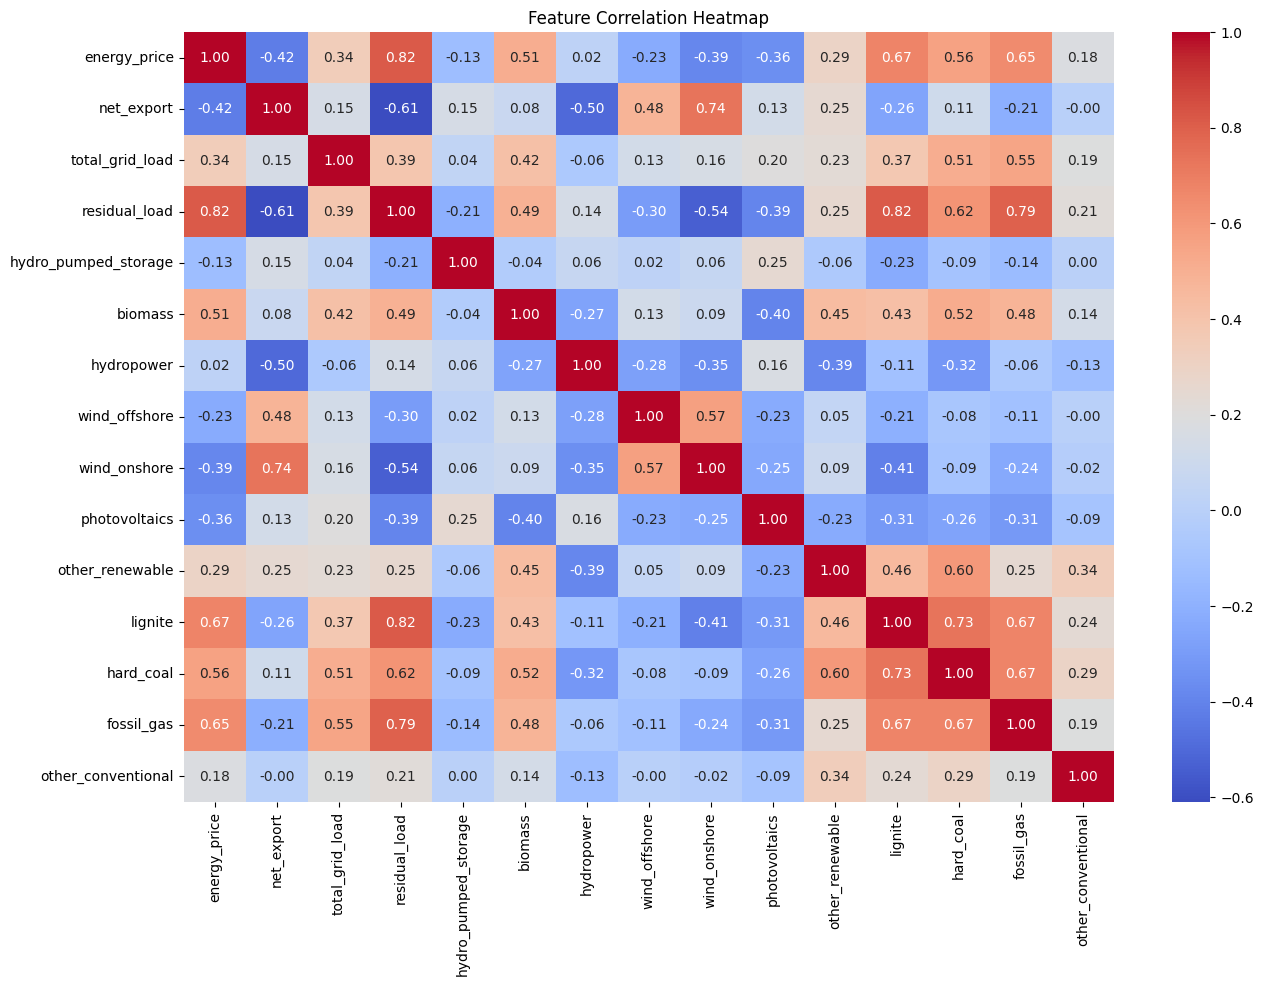

In [913]:
columns= df[[ "energy_price", "net_export", "total_grid_load", "residual_load", 
    "hydro_pumped_storage", "biomass", "hydropower", "wind_offshore", "wind_onshore", 
    "photovoltaics", "other_renewable", "lignite", "hard_coal", "fossil_gas", 
    "other_conventional"]]

plt.figure(figsize=(15,10))
sns.heatmap(columns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


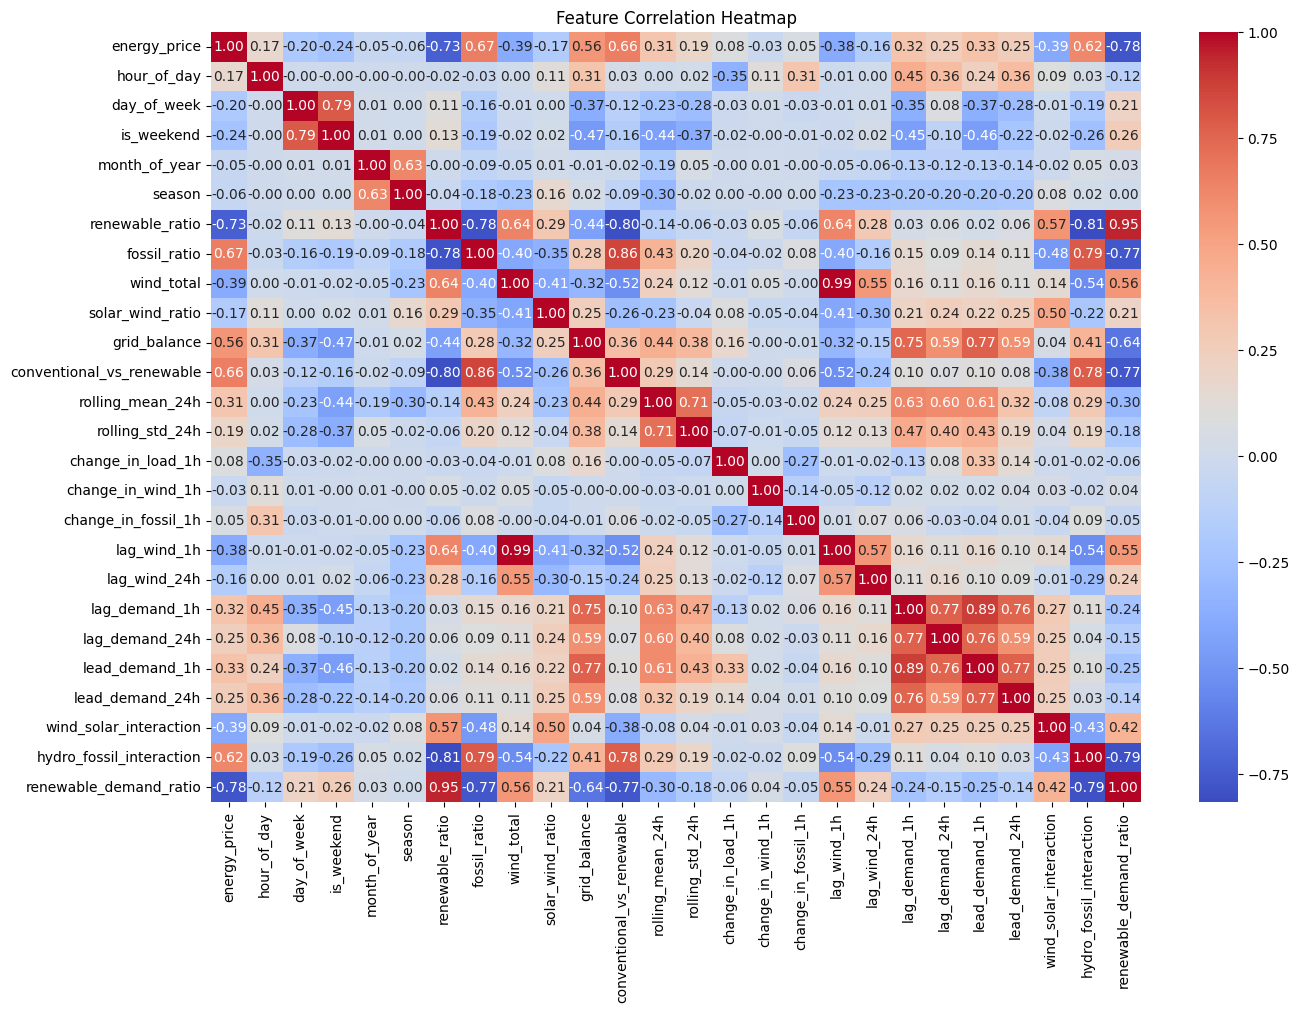

In [914]:
feature_engineer = df[[
      "energy_price", "hour_of_day", "day_of_week", "is_weekend", "month_of_year", 
    "season", "renewable_ratio", "fossil_ratio", "wind_total", "solar_wind_ratio", 
    "grid_balance", "conventional_vs_renewable", "rolling_mean_24h", "rolling_std_24h", 
    "change_in_load_1h", "change_in_wind_1h", "change_in_fossil_1h", "lag_wind_1h", 
    "lag_wind_24h", "lag_demand_1h", "lag_demand_24h", "lead_demand_1h", "lead_demand_24h", 
    "wind_solar_interaction", "hydro_fossil_interaction", "renewable_demand_ratio"
]]

# df_columns = [f"df['{col}']" for col in columns]
# print(df_columns)

plt.figure(figsize=(15,10))
sns.heatmap(feature_engineer.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [915]:
feature_engineer.isna().sum().to_list()

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

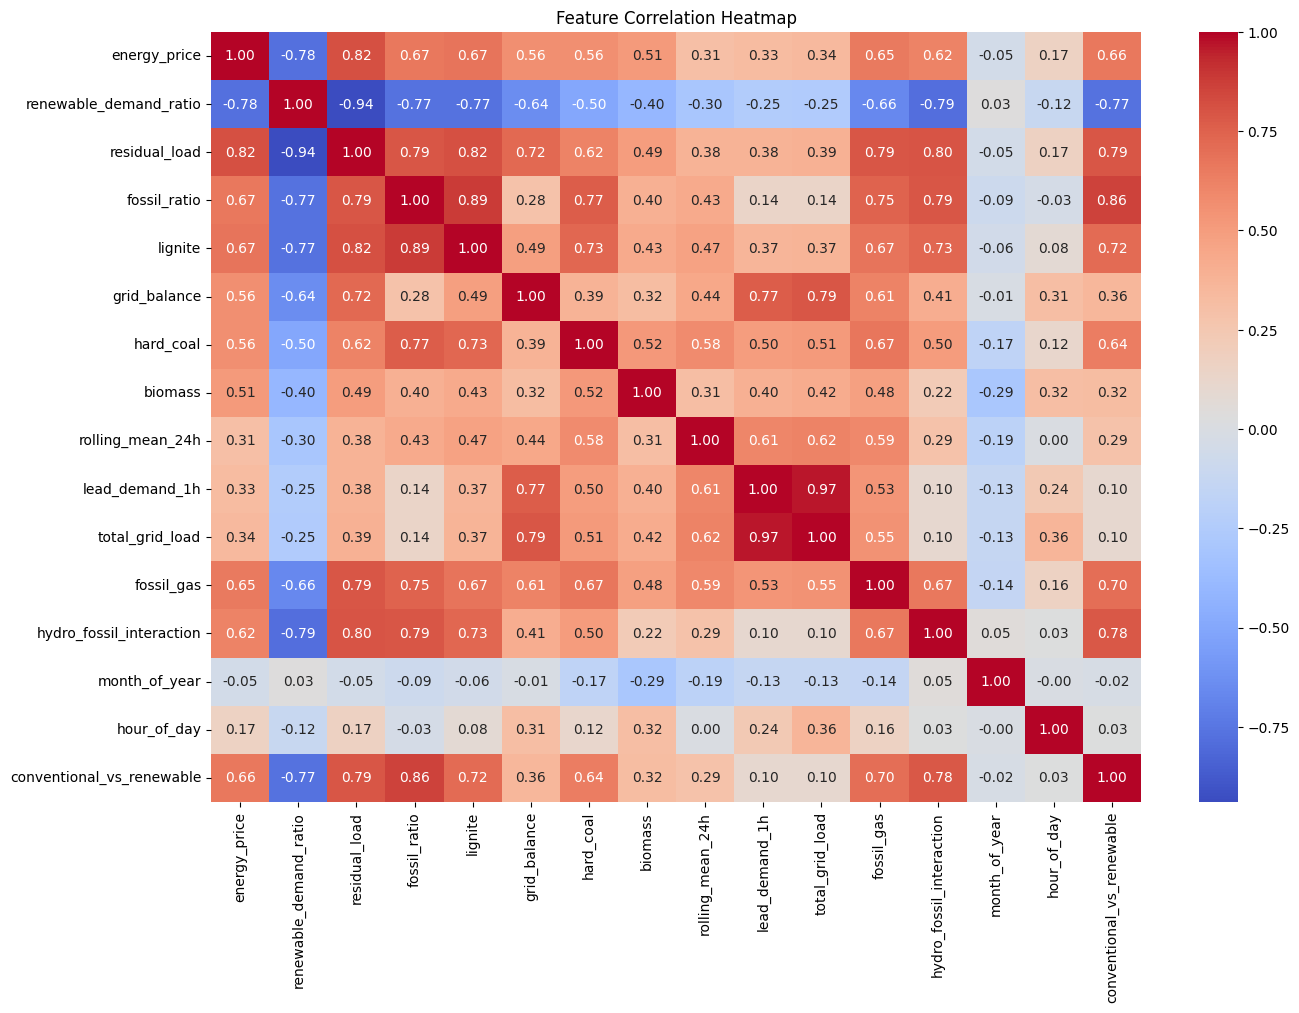

In [916]:
"""These features capture the core dynamics 
of energy prices: the balance between supply 
(renewables vs. fossil fuels) and demand 
(residual_load, total_grid_load), 
as well as temporal trends (lag_demand_1h).
"""

key_features = df[['energy_price','renewable_demand_ratio','residual_load', 'fossil_ratio', 
                   'lignite', 'grid_balance', 'hard_coal', 'biomass',
                   'rolling_mean_24h','lead_demand_1h','total_grid_load',
                   'fossil_gas','hydro_fossil_interaction','month_of_year', 'hour_of_day',
                   'conventional_vs_renewable'
                   ]]

plt.figure(figsize=(15,10))
sns.heatmap(key_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Splitting the Data (Time-Based Split)

In [917]:
# selected_features = ['renewable_demand_ratio','residual_load', 'fossil_ratio', 
#                    'lignite', 'grid_balance', 'hard_coal', 'biomass',
#                    'rolling_mean_24h','lead_demand_1h','total_grid_load',
#                    'fossil_gas','hydro_fossil_interaction','month_of_year', 'hour_of_day',
#                    'conventional_vs_renewable'
#                    ]

selected_features = [
    "hour_of_day", "day_of_week", "is_weekend", "month_of_year", 
    "season", "renewable_ratio", "fossil_ratio", "wind_total", "solar_wind_ratio", 
    "grid_balance", "conventional_vs_renewable", "rolling_mean_24h", "rolling_std_24h", 
    "change_in_load_1h", "change_in_wind_1h", "change_in_fossil_1h", "lag_wind_1h", 
    "lag_wind_24h", "lag_demand_1h", "lag_demand_24h", "lead_demand_1h", "lead_demand_24h", 
    "wind_solar_interaction", "hydro_fossil_interaction", "renewable_demand_ratio"
]

# Features (X) and Target (y)
X = df[selected_features]
y = df['energy_price']

# Time-based train-test split (80% Train, 20% test)
"""Since this is time-series data, I avoid random splits.
 I use a temporal split (e.g., first 80% for training, 
 last 20% for testing)"""

split_idx = int(0.8 * len(df))
X_train , X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
# Proceed with train-test split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Verify shapes
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (15244, 25), Test set: (3812, 25)


# Build and Evaluate Models

I’ll train three models—XGBoost, Random Forest, and Gradient Boosting—and compare their performance using RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error).



### XGBoost

XGBoost Performance:
RMSE: 47.81
MAE: 22.92
Train R^2: 0.9130, Test R^2: 0.4446


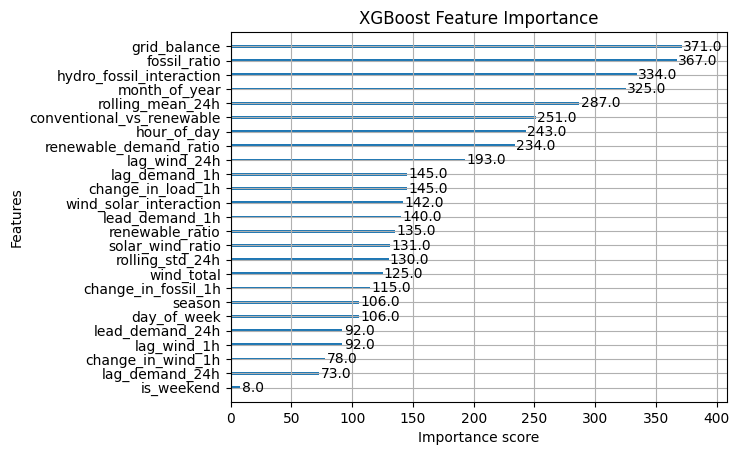

In [918]:
# Initialize and Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 4,
    min_child_weight=3,  # Increase to reduce overfitting
    subsample=0.8,       # Use 80% of data per tree
    colsample_bytree=0.8,  # Use 80% of features per tree
    reg_lambda =1,
    reg_alpha=0.5,
    random_state = 42
)

xgb_model.fit(X_train, y_train)


# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print("XGBoost Performance:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")

# Evaluate
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)
print(f"Train R^2: {train_score:.4f}, Test R^2: {test_score:.4f}")

# Feature importance
xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
plt.show()

### Random Forest

Random Forest Performance:
RMSE: 46.65
MAE: 23.20
Train R^2: 0.9281, Test R^2: 0.4712


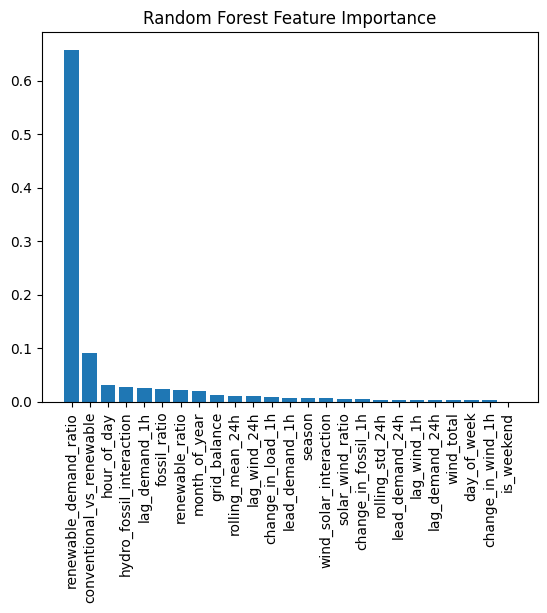

Random Forest - MAE: 23.20, RMSE: 46.65


In [919]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42
    )

rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
print("Random Forest Performance:")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")

# Evaluate
train_score_r = rf_model.score(X_train, y_train)
test_score_r = rf_model.score(X_test, y_test)
print(f"Train R^2: {train_score_r:.4f}, Test R^2: {test_score_r:.4f}")

# Feature importance
importances = rf_model.feature_importances_
feature_importance_rf = pd.Series(importances, index=selected_features).sort_values(ascending=False)
plt.bar(feature_importance_rf.index, feature_importance_rf)
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importance")
plt.show()
print(f"Random Forest - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")


### Gradient Boosting 

Gradient Boosting Performance:
RMSE: 48.33
MAE: 23.45
Train R^2: 0.9294, Test R^2: 0.4325


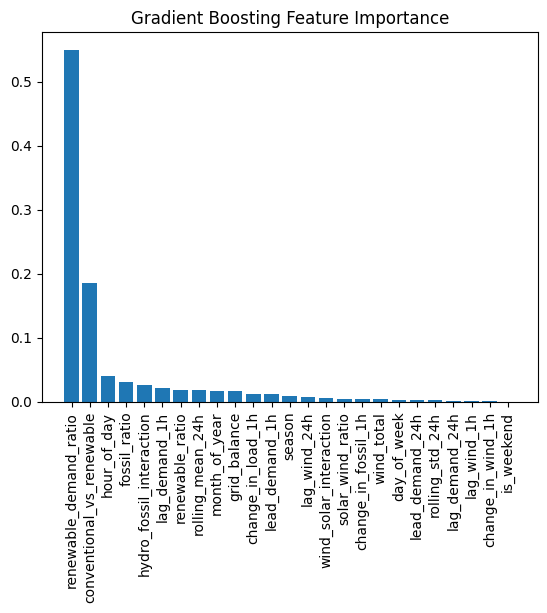

In [920]:
# Initialize and train Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate
rmse_gb = root_mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
print("Gradient Boosting Performance:")
print(f"RMSE: {rmse_gb:.2f}")
print(f"MAE: {mae_gb:.2f}")

# Evaluate
train_score_g = gb_model.score(X_train, y_train)
test_score_g = gb_model.score(X_test, y_test)
print(f"Train R^2: {train_score_g:.4f}, Test R^2: {test_score_g:.4f}")

# Feature importance
importances = gb_model.feature_importances_
feature_importance_gb = pd.Series(importances, index=selected_features).sort_values(ascending=False)
plt.bar(feature_importance_gb.index, feature_importance_gb)
plt.xticks(rotation=90)
plt.title("Gradient Boosting Feature Importance")
plt.show()

## Model Performance Comparison


Model Performance Summary:
               Model       RMSE        MAE
0            XGBoost  47.811387  22.921933
1      Random Forest  46.653015  23.198320
2  Gradient Boosting  48.326442  23.451983


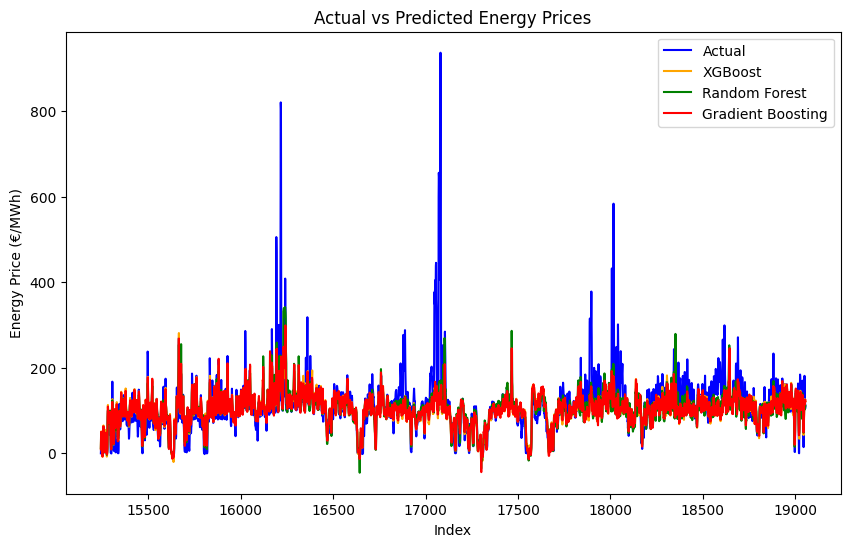

In [921]:
# Performance summary
performance = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_xgb, rmse_rf, rmse_gb],
    'MAE': [mae_xgb, mae_rf, mae_gb]
})
print("\nModel Performance Summary:")
print(performance)

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_xgb, label='XGBoost', color='orange')
plt.plot(y_test.index, y_pred_rf, label='Random Forest', color='green')
plt.plot(y_test.index, y_pred_gb, label='Gradient Boosting', color='red')
plt.legend()
plt.title("Actual vs Predicted Energy Prices")
plt.xlabel("Index")
plt.ylabel("Energy Price (€/MWh)")
plt.show()

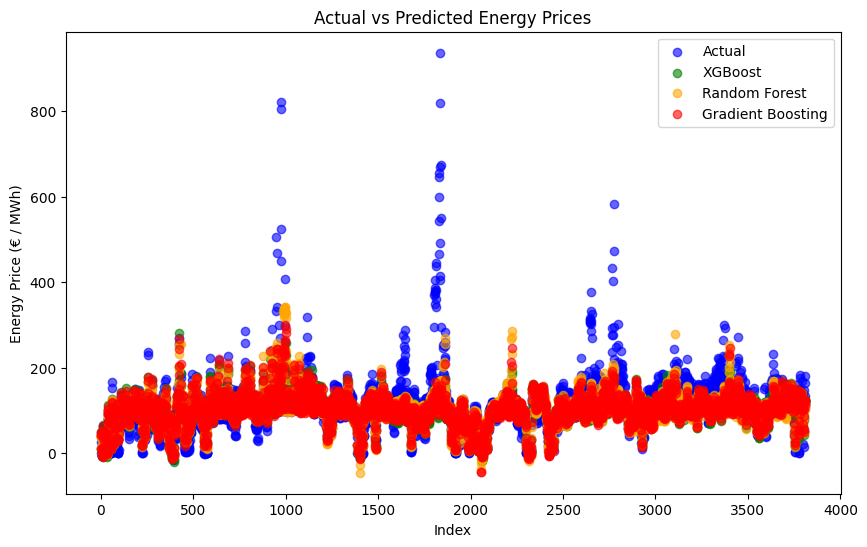

In [922]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test)), y_test, color="blue", label="Actual", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_xgb, color="green", label="XGBoost", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_rf, color="orange", label="Random Forest", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_gb, color="red", label="Gradient Boosting", alpha=0.6)
plt.xlabel("Index")
plt.ylabel("Energy Price (€ / MWh)")
plt.title("Actual vs Predicted Energy Prices")
plt.legend()
plt.show()


In [923]:
from xgboost import XGBRegressor

# Define target variable and features
target = 'energy_price'  # Replace with actual target column
# features = [
#     'Renewable_demand_ratio', 'Conventional_vs_renewable', 'Grid balance', 'Fossil ratio',
#     'Hydro_fossil_interaction', 'Rolling mean 24h', 'Hour of day', 'Month of year', 'Lag demand 1h',
#     'Lead demand 1h', 'Wind-solar interaction', 'Solar wind ratio', 'Rolling std 24h',
#     'Change_in_load_1h', 'Wind total'
# ]

features = [
    "renewable_demand_ratio","conventional_vs_renewable","grid_balance","fossil_ratio",
    "hydro_fossil_interaction","rolling_mean_24h","hour_of_day","month_of_year","lag_demand_1h",
    "lead_demand_1h","wind_solar_interaction","solar_wind_ratio","rolling_std_24h",
    "change_in_load_1h","wind_total"
]

X = df[features]
y = df[target]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(root_mean_squared_error(y_test, y_pred))
    mae_gb = mean_absolute_error(y_test, y_pred_gb)
    print(f"{name} RMSE: {rmse:.4f}")
    # Evaluate
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f"Train R^2: {train_score:.4f}, Test R^2: {test_score:.4f}")



Random Forest RMSE: 4.0896
Train R^2: 0.9812, Test R^2: 0.8989
Gradient Boosting RMSE: 4.6372
Train R^2: 0.8469, Test R^2: 0.8329
XGBoost RMSE: 3.9796
Train R^2: 0.9466, Test R^2: 0.9094


Train R^2: 0.9466, Test R^2: 0.9094
Train R^2: 0.9812, Test R^2: 0.8989
Train R^2: 0.8469, Test R^2: 0.8329

Model Performance Summary:
               Model       RMSE        MAE
0            XGBoost  15.837295  10.827595
1      Random Forest  16.724944  10.997898
2  Gradient Boosting  21.503249  14.653261


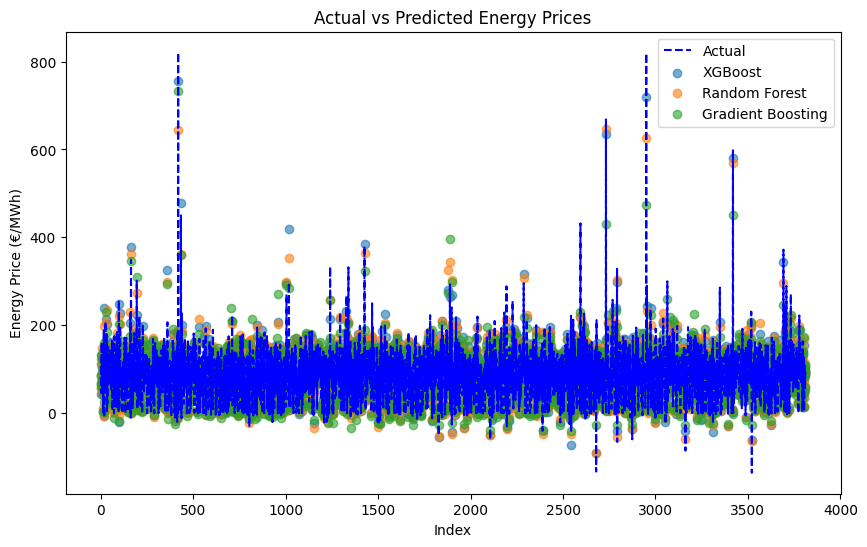

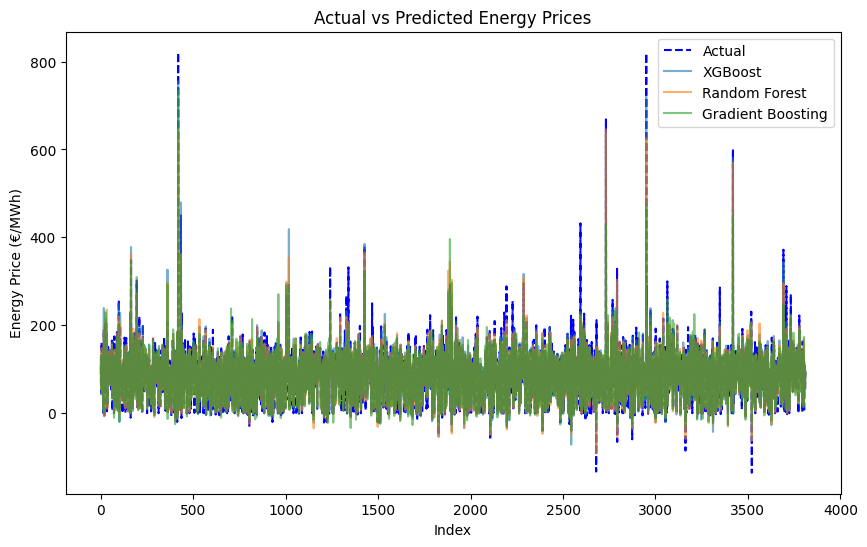

In [927]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Define features and target variable
target = "energy_price"
features = [
    "renewable_demand_ratio", "conventional_vs_renewable", "grid_balance", "fossil_ratio",
    "hydro_fossil_interaction", "rolling_mean_24h", "hour_of_day", "month_of_year", "lag_demand_1h",
    "lead_demand_1h", "wind_solar_interaction", "solar_wind_ratio", "rolling_std_24h",
    "change_in_load_1h", "wind_total"
]

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Store results
results = {"Model": [], "RMSE": [], "MAE": []}
predictions = {}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Compute metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Store results
    results["Model"].append(name)
    results["RMSE"].append(rmse)
    results["MAE"].append(mae)
    # Evaluate
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f"Train R^2: {train_score:.4f}, Test R^2: {test_score:.4f}")
    #print(f"Train R^2: {train_score:.4f}, Test R^2: {test_score:.4f}")
    predictions[name] = y_pred

# Convert results to DataFrame
performance = pd.DataFrame(results)

# Print Performance Summary
print("\nModel Performance Summary:")
print(performance)

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', color='blue', linestyle="dashed")

for name, y_pred in predictions.items():
    plt.scatter(range(len(y_pred)), y_pred, label=name, alpha=0.6)

plt.legend()
plt.title("Actual vs Predicted Energy Prices")
plt.xlabel("Index")
plt.ylabel("Energy Price (€/MWh)")
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', color='blue', linestyle="dashed")

for name, y_pred in predictions.items():
    plt.plot(range(len(y_pred)), y_pred, label=name, alpha=0.6)

# plt.figure(figsize=(10, 6))
# plt.plot(y_test.index, y_test, label='Actual', color='blue')
# plt.plot(y_test.index, y_pred_xgb, label='XGBoost', color='orange')
# plt.plot(y_test.index, y_pred_rf, label='Random Forest', color='green')
# plt.plot(y_test.index, y_pred_gb, label='Gradient Boosting', color='red')
plt.legend()
plt.title("Actual vs Predicted Energy Prices")
plt.xlabel("Index")
plt.ylabel("Energy Price (€/MWh)")
plt.show()

# Hyperparameter Tuning

#### Tuning XGBoost (the best model)



In [926]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3, 5],  # Controls overfitting
#     'subsample': [0.7, 0.8, 1.0],  # Fraction of samples used per tree
#     'colsample_bytree': [0.7, 0.8, 1.0]  # Fraction of features used per tree
# }


# grid_search = GridSearchCV(
#     estimator=xgb.XGBRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=3,
#     scoring='neg_mean_squared_error',
#     verbose=1
# )
# grid_search.fit(X_train, y_train)
# best_xgb_model = grid_search.best_estimator_
# y_pred_best_xgb = best_xgb_model.predict(X_test)
# rmse_best_xgb = root_mean_squared_error(y_test, y_pred_best_xgb)
# mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
# print(f"Tuned XGBoost (MAE Optimized) RMSE: {rmse_best_xgb:.2f}")
# print(f"Tuned XGBoost (MAE Optimized) MAE: {mae_best_xgb:.2f}")

# # Evaluate
# train_score_d = grid_search.score(X_train, y_train)
# test_score_d = grid_search.score(X_test, y_test)
# print(f"Train R^2: {train_score:.4f}, Test R^2: {test_score:.4f}")